# Step 1: Imports #

We begin by importing several Python packages.

In [1]:
import math, re, os
import numpy as np
import tensorflow as tf

print("Tensorflow version " + tf.__version__)

2026-09-26 19:46:15.309865: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-26 19:46:15.310110: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-26 19:46:15.467787: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Tensorflow version 2.15.0


# Step 2: Distribution Strategy #

A TPU has eight different *cores* and each of these cores acts as its own accelerator. (A TPU is sort of like having eight GPUs in one machine.) We tell TensorFlow how to make use of all these cores at once through a **distribution strategy**. Run the following cell to create the distribution strategy that we'll later apply to our model.

In [2]:
# Detect TPU, return appropriate distribution strategy
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver() 
    print('Running on TPU ', tpu.master())
except ValueError:
    tpu = None

if tpu:
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
else:
    strategy = tf.distribute.get_strategy() 

print("REPLICAS: ", strategy.num_replicas_in_sync)

REPLICAS:  1


We'll use the distribution strategy when we create our neural network model. Then, TensorFlow will distribute the training among the eight TPU cores by creating eight different *replicas* of the model, one for each core.

# Step 3: Loading the Competition Data #

## Get GCS Path ##

When used with TPUs, datasets need to be stored in a [Google Cloud Storage bucket](https://cloud.google.com/storage/). You can use data from any public GCS bucket by giving its path just like you would data from `'/kaggle/input'`. The following will retrieve the GCS path for this competition's dataset.

In [3]:
from kaggle_datasets import KaggleDatasets

GCS_DS_PATH = KaggleDatasets().get_gcs_path('tpu-getting-started')
print(GCS_DS_PATH) # what do gcs paths look like?

gs://kds-8d63603adcd4e21a3433c1e4438ca146c0c8d4adc0224af2b788f5da


You can use data from any public dataset here on Kaggle in just the same way. If you'd like to use data from one of your private datasets, see [here](https://www.kaggle.com/docs/tpu#tpu3pt5).

## Load Data ##

When used with TPUs, datasets are often serialized into [TFRecords](https://www.kaggle.com/ryanholbrook/tfrecords-basics). This is a format convenient for distributing data to each of the TPUs cores. We've hidden the cell that reads the TFRecords for our dataset since the process is a bit long. You could come back to it later for some guidance on using your own datasets with TPUs.

In [4]:

IMAGE_SIZE = [384, 384]
GCS_PATH = GCS_DS_PATH + '/tfrecords-jpeg-512x512'
AUTO = tf.data.experimental.AUTOTUNE

TRAINING_FILENAMES = tf.io.gfile.glob(GCS_PATH + '/train/*.tfrec')
VALIDATION_FILENAMES = tf.io.gfile.glob(GCS_PATH + '/val/*.tfrec')
TEST_FILENAMES = tf.io.gfile.glob(GCS_PATH + '/test/*.tfrec') 

CLASSES = ['pink primrose',    'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea',     'wild geranium',     'tiger lily',           'moon orchid',              'bird of paradise', 'monkshood',        'globe thistle',         # 00 - 09
           'snapdragon',       "colt's foot",               'king protea',      'spear thistle', 'yellow iris',       'globe-flower',         'purple coneflower',        'peruvian lily',    'balloon flower',   'giant white arum lily', # 10 - 19
           'fire lily',        'pincushion flower',         'fritillary',       'red ginger',    'grape hyacinth',    'corn poppy',           'prince of wales feathers', 'stemless gentian', 'artichoke',        'sweet william',         # 20 - 29
           'carnation',        'garden phlox',              'love in the mist', 'cosmos',        'alpine sea holly',  'ruby-lipped cattleya', 'cape flower',              'great masterwort', 'siam tulip',       'lenten rose',           # 30 - 39
           'barberton daisy',  'daffodil',                  'sword lily',       'poinsettia',    'bolero deep blue',  'wallflower',           'marigold',                 'buttercup',        'daisy',            'common dandelion',      # 40 - 49
           'petunia',          'wild pansy',                'primula',          'sunflower',     'lilac hibiscus',    'bishop of llandaff',   'gaura',                    'geranium',         'orange dahlia',    'pink-yellow dahlia',    # 50 - 59
           'cautleya spicata', 'japanese anemone',          'black-eyed susan', 'silverbush',    'californian poppy', 'osteospermum',         'spring crocus',            'iris',             'windflower',       'tree poppy',            # 60 - 69
           'gazania',          'azalea',                    'water lily',       'rose',          'thorn apple',       'morning glory',        'passion flower',           'lotus',            'toad lily',        'anthurium',             # 70 - 79
           'frangipani',       'clematis',                  'hibiscus',         'columbine',     'desert-rose',       'tree mallow',          'magnolia',                 'cyclamen ',        'watercress',       'canna lily',            # 80 - 89
           'hippeastrum ',     'bee balm',                  'pink quill',       'foxglove',      'bougainvillea',     'camellia',             'mallow',                   'mexican petunia',  'bromelia',         'blanket flower',        # 90 - 99
           'trumpet creeper',  'blackberry lily',           'common tulip',     'wild rose']                                                                                                                                               # 100 - 102


def decode_image(image_data):
    image = tf.image.decode_jpeg(image_data, channels=3)
    image = tf.cast(image, tf.float32) / 255.0  # convert image to floats in [0, 1] range
    image = tf.image.resize(image, IMAGE_SIZE) # explicit size needed for TPU
    return image

def read_labeled_tfrecord(example):
    LABELED_TFREC_FORMAT = {
        "image": tf.io.FixedLenFeature([], tf.string), # tf.string means bytestring
        "class": tf.io.FixedLenFeature([], tf.int64),  # shape [] means single element
    }
    example = tf.io.parse_single_example(example, LABELED_TFREC_FORMAT)
    image = decode_image(example['image'])
    label = tf.cast(example['class'], tf.int32)
    return image, label # returns a dataset of (image, label) pairs

def read_unlabeled_tfrecord(example):
    UNLABELED_TFREC_FORMAT = {
        "image": tf.io.FixedLenFeature([], tf.string), # tf.string means bytestring
        "id": tf.io.FixedLenFeature([], tf.string),  # shape [] means single element
        # class is missing, this competitions's challenge is to predict flower classes for the test dataset
    }
    example = tf.io.parse_single_example(example, UNLABELED_TFREC_FORMAT)
    image = decode_image(example['image'])
    idnum = example['id']
    return image, idnum # returns a dataset of image(s)

def load_dataset(filenames, labeled=True, ordered=False):
    # Read from TFRecords. For optimal performance, reading from multiple files at once and
    # disregarding data order. Order does not matter since we will be shuffling the data anyway.

    ignore_order = tf.data.Options()
    if not ordered:
        ignore_order.experimental_deterministic = False # disable order, increase speed

    dataset = tf.data.TFRecordDataset(filenames, num_parallel_reads=AUTO) # automatically interleaves reads from multiple files
    dataset = dataset.with_options(ignore_order) # uses data as soon as it streams in, rather than in its original order
    dataset = dataset.map(read_labeled_tfrecord if labeled else read_unlabeled_tfrecord, num_parallel_calls=AUTO)
    # returns a dataset of (image, label) pairs if labeled=True or (image, id) pairs if labeled=False
    return dataset

## Create Data Pipelines ##

In this final step we'll use the `tf.data` API to define an efficient data pipeline for each of the training, validation, and test splits.

In [5]:

def data_augment(image, label):
    # Thanks to the dataset.prefetch(AUTO)
    # statement in the next function (below), this happens essentially
    # for free on TPU. Data pipeline code is executed on the "CPU"
    # part of the TPU while the TPU itself is computing gradients.
    image = tf.image.random_flip_left_right(image)
    #image = tf.image.random_saturation(image, 0, 2)
    return image, label   

def get_training_dataset():
    dataset = load_dataset(TRAINING_FILENAMES, labeled=True)
    dataset = dataset.map(data_augment, num_parallel_calls=AUTO)
    dataset = dataset.repeat() # the training dataset must repeat for several epochs
    dataset = dataset.shuffle(2048)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTO) # prefetch next batch while training (autotune prefetch buffer size)
    return dataset

def get_validation_dataset(ordered=False):
    dataset = load_dataset(VALIDATION_FILENAMES, labeled=True, ordered=ordered)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.cache()
    dataset = dataset.prefetch(AUTO)
    return dataset

def get_test_dataset(ordered=False):
    dataset = load_dataset(TEST_FILENAMES, labeled=False, ordered=ordered)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTO)
    return dataset

def count_data_items(filenames):
    # the number of data items is written in the name of the .tfrec
    # files, i.e. flowers00-230.tfrec = 230 data items
    n = [int(re.compile(r"-([0-9]*)\.").search(filename).group(1)) for filename in filenames]
    return np.sum(n)

NUM_TRAINING_IMAGES = count_data_items(TRAINING_FILENAMES)
NUM_VALIDATION_IMAGES = count_data_items(VALIDATION_FILENAMES)
NUM_TEST_IMAGES = count_data_items(TEST_FILENAMES)
print('Dataset: {} training images, {} validation images, {} unlabeled test images'.format(NUM_TRAINING_IMAGES, NUM_VALIDATION_IMAGES, NUM_TEST_IMAGES))


Dataset: 12753 training images, 3712 validation images, 7382 unlabeled test images


This next cell will create the datasets that we'll use with Keras during training and inference. Notice how we scale the size of the batches to the number of TPU cores.

In [6]:
# Define the batch size. This will be 16 with TPU off and 128 (=16*8) with TPU on
BATCH_SIZE = 16 * strategy.num_replicas_in_sync

ds_train = get_training_dataset()
ds_valid = get_validation_dataset()
ds_test = get_test_dataset()

print("Training:", ds_train)
print ("Validation:", ds_valid)
print("Test:", ds_test)

Training: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 384, 384, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Validation: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 384, 384, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Test: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 384, 384, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.string, name=None))>


These datasets are `tf.data.Dataset` objects. You can think about a dataset in TensorFlow as a *stream* of data records. The training and validation sets are streams of `(image, label)` pairs.

In [7]:
np.set_printoptions(threshold=15, linewidth=80)

print("Training data shapes:")
for image, label in ds_train.take(3):
    print(image.numpy().shape, label.numpy().shape)
print("Training data label examples:", label.numpy())

Training data shapes:
(16, 384, 384, 3) (16,)
(16, 384, 384, 3) (16,)
(16, 384, 384, 3) (16,)
Training data label examples: [95 64 67 ... 50 18 73]


The test set is a stream of `(image, idnum)` pairs; `idnum` here is the unique identifier given to the image that we'll use later when we make our submission as a `csv` file.

In [8]:
print("Test data shapes:")
for image, idnum in ds_test.take(3):
    print(image.numpy().shape, idnum.numpy().shape)
print("Test data IDs:", idnum.numpy().astype('U')) # U=unicode string

Test data shapes:
(16, 384, 384, 3) (16,)
(16, 384, 384, 3) (16,)
(16, 384, 384, 3) (16,)
Test data IDs: ['a1a2e7691' '22f63c29b' 'fe2bfa700' ... '54493a1bd' '5b3c21bc7' '558548e53']


# Step 4: Explore Data #

Let's take a moment to look at some of the images in the dataset.

In [9]:

from matplotlib import pyplot as plt

def batch_to_numpy_images_and_labels(data):
    images, labels = data
    numpy_images = images.numpy()
    numpy_labels = labels.numpy()
    if numpy_labels.dtype == object: # binary string in this case,
                                     # these are image ID strings
        numpy_labels = [None for _ in enumerate(numpy_images)]
    # If no labels, only image IDs, return None for labels (this is
    # the case for test data)
    return numpy_images, numpy_labels

def title_from_label_and_target(label, correct_label):
    if correct_label is None:
        return CLASSES[label], True
    correct = (label == correct_label)
    return "{} [{}{}{}]".format(CLASSES[label], 'OK' if correct else 'NO', u"\u2192" if not correct else '',
                                CLASSES[correct_label] if not correct else ''), correct

def display_one_flower(image, title, subplot, red=False, titlesize=16):
    plt.subplot(*subplot)
    plt.axis('off')
    plt.imshow(image)
    if len(title) > 0:
        plt.title(title, fontsize=int(titlesize) if not red else int(titlesize/1.2), color='red' if red else 'black', fontdict={'verticalalignment':'center'}, pad=int(titlesize/1.5))
    return (subplot[0], subplot[1], subplot[2]+1)
    
def display_batch_of_images(databatch, predictions=None):
    """This will work with:
    display_batch_of_images(images)
    display_batch_of_images(images, predictions)
    display_batch_of_images((images, labels))
    display_batch_of_images((images, labels), predictions)
    """
    # data
    images, labels = batch_to_numpy_images_and_labels(databatch)
    if labels is None:
        labels = [None for _ in enumerate(images)]
        
    # auto-squaring: this will drop data that does not fit into square
    # or square-ish rectangle
    rows = int(math.sqrt(len(images)))
    cols = len(images)//rows
        
    # size and spacing
    FIGSIZE = 13.0
    SPACING = 0.1
    subplot=(rows,cols,1)
    if rows < cols:
        plt.figure(figsize=(FIGSIZE,FIGSIZE/cols*rows))
    else:
        plt.figure(figsize=(FIGSIZE/rows*cols,FIGSIZE))
    
    # display
    for i, (image, label) in enumerate(zip(images[:rows*cols], labels[:rows*cols])):
        title = '' if label is None else CLASSES[label]
        correct = True
        if predictions is not None:
            title, correct = title_from_label_and_target(predictions[i], label)
        dynamic_titlesize = FIGSIZE*SPACING/max(rows,cols)*40+3 # magic formula tested to work from 1x1 to 10x10 images
        subplot = display_one_flower(image, title, subplot, not correct, titlesize=dynamic_titlesize)
    
    #layout
    plt.tight_layout()
    if label is None and predictions is None:
        plt.subplots_adjust(wspace=0, hspace=0)
    else:
        plt.subplots_adjust(wspace=SPACING, hspace=SPACING)
    plt.show()


def display_training_curves(training, validation, title, subplot):
    if subplot%10==1: # set up the subplots on the first call
        plt.subplots(figsize=(10,10), facecolor='#F0F0F0')
        plt.tight_layout()
    ax = plt.subplot(subplot)
    ax.set_facecolor('#F8F8F8')
    ax.plot(training)
    ax.plot(validation)
    ax.set_title('model '+ title)
    ax.set_ylabel(title)
    #ax.set_ylim(0.28,1.05)
    ax.set_xlabel('epoch')
    ax.legend(['train', 'valid.'])

You can display a single batch of images from a dataset with another of our helper functions. The next cell will turn the dataset into an iterator of batches of 20 images.

In [10]:
ds_iter = iter(ds_train.unbatch().batch(20))

Use the Python `next` function to pop out the next batch in the stream and display it with the helper function.

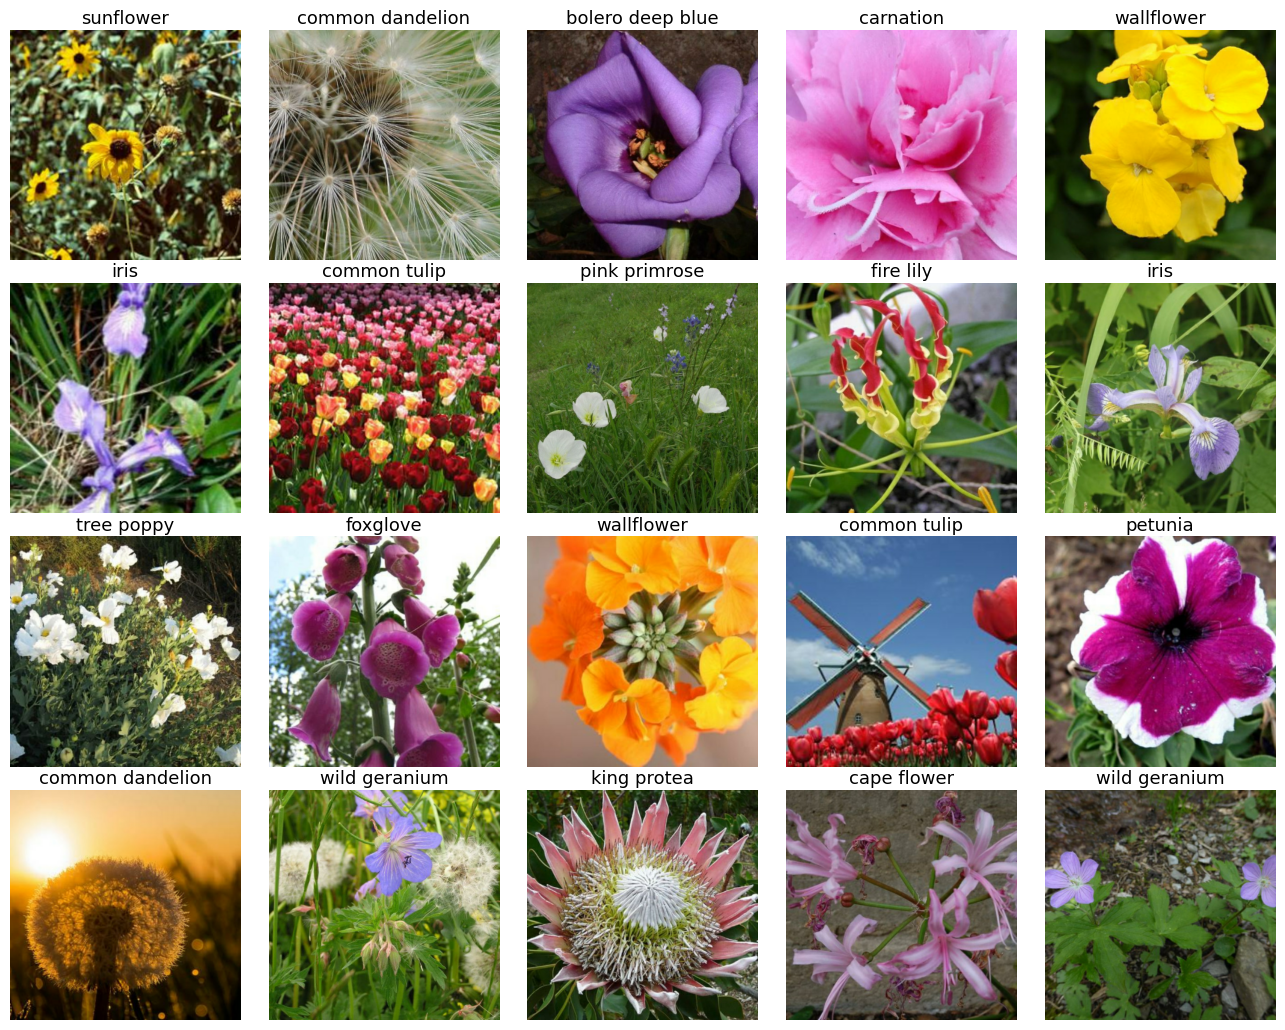

In [11]:
one_batch = next(ds_iter)
display_batch_of_images(one_batch)

By defining `ds_iter` and `one_batch` in separate cells, you only need to rerun the cell above to see a new batch of images.

# Step 5: Define Model #

Now we're ready to create a neural network for classifying images! We'll use what's known as **transfer learning**. With transfer learning, you reuse part of a pretrained model to get a head-start on a new dataset.

For this tutorial, we'll to use a model called **EfficientNetV2S** pretrained on [ImageNet](http://image-net.org/)). Later, you might want to experiment with [other models](https://www.tensorflow.org/api_docs/python/tf/keras/applications) included with Keras. ([Xception](https://www.tensorflow.org/api_docs/python/tf/keras/applications/Xception) wouldn't be a bad choice.)

The distribution strategy we created earlier contains a [context manager](https://docs.python.org/3/reference/compound_stmts.html#with), `strategy.scope`. This context manager tells TensorFlow how to divide the work of training among the eight TPU cores. When using TensorFlow with a TPU, it's important to define your model in a `strategy.scope()` context.

In [12]:
def build_model(dropout_rate, dense_units):
    with strategy.scope():
        base_model = tf.keras.applications.EfficientNetV2S(
            weights="imagenet",
            include_top=False,
            input_shape=(*IMAGE_SIZE, 3)
        )

        base_model.trainable = False

        inputs = tf.keras.Input(
            shape=(*IMAGE_SIZE, 3)
        )

        x = base_model(inputs, training=False)
        x = tf.keras.layers.GlobalAveragePooling2D()(x)
        x = tf.keras.layers.Dropout(dropout_rate)(x)
        x = tf.keras.layers.Dense(dense_units, activation="relu")(x)
        outputs = tf.keras.layers.Dense(len(CLASSES), activation="softmax")(x)
        model = tf.keras.Model(inputs, outputs)

    return model

In [13]:
!pip install -q optuna-integration

In [14]:
import gc
import optuna
from optuna.integration import TFKerasPruningCallback

STEPS_PER_EPOCH = NUM_TRAINING_IMAGES // BATCH_SIZE
TUNE_EPOCHS = 6
TUNE_STEPS_PER_EPOCH = min(150, STEPS_PER_EPOCH)
TUNE_VALIDATION_STEPS = 50

In [15]:
def exponential_lr(epoch, start_lr, min_lr, max_lr, rampup_epochs, sustain_epochs, exp_decay):
    if epoch < rampup_epochs:
        if rampup_epochs == 0:
            lr = max_lr
        else:
            lr = ((max_lr - start_lr) / rampup_epochs * epoch + start_lr)

    elif epoch < rampup_epochs + sustain_epochs:
        lr = max_lr

    else:
        lr = ((max_lr - min_lr) * exp_decay ** ( epoch - rampup_epochs - sustain_epochs) + min_lr)

    return lr

In [16]:
def objective(trial):

    dropout_rate = trial.suggest_float("dropout", 0.2, 0.5)
    dense_units = trial.suggest_categorical("dense_units", [128, 256, 512])
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "adamw", "rmsprop"])
    max_lr = trial.suggest_float("max_lr", 1e-5, 3e-4, log=True)
    exp_decay = trial.suggest_float("exp_decay", 0.80, 0.98)
    rampup_epochs = trial.suggest_int("rampup_epochs", 0, 2)
    sustain_epochs = trial.suggest_int("sustain_epochs", 0, 1)
    start_factor = trial.suggest_float("start_factor", 0.1, 0.5)
    min_factor = trial.suggest_float("min_factor", 0.01, 0.1)
    start_lr = max_lr * start_factor
    min_lr = max_lr * min_factor
    model = build_model(dropout_rate=dropout_rate, dense_units=dense_units)

    if optimizer_name == "adam":

        optimizer = tf.keras.optimizers.Adam(learning_rate=max_lr)

    elif optimizer_name == "adamw":

        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        optimizer = tf.keras.optimizers.AdamW(learning_rate=max_lr, weight_decay=weight_decay)

    else:

        optimizer = tf.keras.optimizers.RMSprop(learning_rate=max_lr)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["sparse_categorical_accuracy"]
    )

    def custom_lr(epoch):
        return exponential_lr(
            epoch=epoch,
            start_lr=start_lr,
            min_lr=min_lr,
            max_lr=max_lr,
            rampup_epochs=rampup_epochs,
            sustain_epochs=sustain_epochs,
            exp_decay=exp_decay
        )

    lr_callback = tf.keras.callbacks.LearningRateScheduler(custom_lr, verbose=0)

    pruning_callback = TFKerasPruningCallback(trial, "val_sparse_categorical_accuracy")

    history = model.fit(
        ds_train,
        validation_data=ds_valid,
        epochs=TUNE_EPOCHS,
        steps_per_epoch=TUNE_STEPS_PER_EPOCH,
        validation_steps=TUNE_VALIDATION_STEPS,
        callbacks=[
            lr_callback,
            pruning_callback
        ],
        verbose=0
    )

    best_val_acc = max(
        history.history["val_sparse_categorical_accuracy"]
    )

    del model
    tf.keras.backend.clear_session()
    gc.collect()

    return best_val_acc

The `'sparse_categorical'` versions of the loss and metrics are appropriate for a classification task with more than two labels, like this one.

In [17]:
import joblib
import shutil

shutil.copy(
    "/kaggle/input/datasets/davibaca/study-parameters/keras_optuna.db",
    "/kaggle/working/keras_optuna.db"
)
study = optuna.load_study(
    study_name="efficientnetv2s_tuning",
    storage="sqlite:////kaggle/working/keras_optuna.db"
)

# study = optuna.create_study(
#      study_name="efficientnetv2s_tuning",
#      storage=storage_name,
#      direction="maximize",
#      sampler=optuna.samplers.TPESampler(seed=42,n_startup_trials=8),
#      pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=2, interval_steps=1),
#      load_if_exists=True)

print(f"Trials already done: {len(study.trials)}")

study.optimize(
    objective,
    n_trials=8,  
    timeout=10 * 3600,
    catch=(tf.errors.ResourceExhaustedError,)
)

joblib.dump(study, "/kaggle/working/study.pkl")

print("Best validation accuracy:")
print(study.best_value)

print("\nBest parameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

Trials already done: 8
82420632/82420632 [==============================] - 0s 0us/step


[I 2026-09-26 21:14:36,697] Trial 8 finished with value: 0.09749999642372131 and parameters: {'dropout': 0.29232573745006285, 'dense_units': 512, 'optimizer': 'adamw', 'max_lr': 7.646899387818838e-05, 'exp_decay': 0.9036538443023331, 'rampup_epochs': 1, 'sustain_epochs': 0, 'start_factor': 0.3374616251395076, 'min_factor': 0.03766933282930162, 'weight_decay': 0.00048556410092063433}. Best is trial 1 with value: 0.10000000149011612.
[I 2026-09-26 21:29:41,976] Trial 9 pruned. Trial was pruned at epoch 0.
[I 2026-09-26 22:31:03,328] Trial 10 pruned. Trial was pruned at epoch 3.
[I 2026-09-26 23:14:11,958] Trial 11 pruned. Trial was pruned at epoch 2.
[I 2026-09-27 00:42:23,212] Trial 12 finished with value: 0.09875000268220901 and parameters: {'dropout': 0.28008245463287607, 'dense_units': 512, 'optimizer': 'adamw', 'max_lr': 9.998669961431008e-05, 'exp_decay': 0.8422057252241405, 'rampup_epochs': 1, 'sustain_epochs': 0, 'start_factor': 0.23751681571547667, 'min_factor': 0.02539513381174

Best validation accuracy:
0.10000000149011612

Best parameters:
dropout: 0.26370173320348284
dense_units: 512
optimizer: adam
max_lr: 8.01273750399854e-05
exp_decay: 0.8251088949173676
rampup_epochs: 0
sustain_epochs: 0
start_factor: 0.28242799368681437
min_factor: 0.08066583652537122


In [18]:
best_params = study.best_params

model = build_model(
    dropout_rate=best_params["dropout"],
    dense_units=best_params["dense_units"]
)

if best_params["optimizer"] == "adam":

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=best_params["max_lr"]
    )

elif best_params["optimizer"] == "adamw":

    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=best_params["max_lr"],
        weight_decay=best_params["weight_decay"]
    )

else:

    optimizer = tf.keras.optimizers.RMSprop(
        learning_rate=best_params["max_lr"]
    )

model.compile(
    optimizer= optimizer,
    loss = 'sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy'],
)

model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 384, 384, 3)]     0         
                                                                 
 efficientnetv2-s (Function  (None, 12, 12, 1280)      20331360  
 al)                                                             
                                                                 
 global_average_pooling2d_2  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dropout_2 (Dropout)         (None, 1280)              0         
                                                                 
 dense_4 (Dense)             (None, 512)               655872    
                                                                 
 dense_5 (Dense)             (None, 104)               5335

# Step 6: Training #

## Learning Rate Schedule ##

We'll train this network with a special learning rate schedule.

In [19]:
best_max_lr = best_params["max_lr"]

best_start_lr = (
    best_max_lr * best_params["start_factor"]
)

best_min_lr = (
    best_max_lr * best_params["min_factor"]
)

def best_lr_schedule(epoch):

    return exponential_lr(
        epoch=epoch,
        start_lr=best_start_lr,
        min_lr=best_min_lr,
        max_lr=best_max_lr,
        rampup_epochs=best_params["rampup_epochs"],
        sustain_epochs=best_params["sustain_epochs"],
        exp_decay=best_params["exp_decay"]
    )

lr_callback = tf.keras.callbacks.LearningRateScheduler(
    best_lr_schedule,
    verbose=1
)



## Fit Model ##

And now we're ready to train the model. After defining a few parameters, we're good to go!

In [20]:
#checkpoint_filepath = "/kaggle/working/best_head_model.keras"

#model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
#    filepath=checkpoint_filepath,
#    monitor="val_sparse_categorical_accuracy",
#    mode="max",
#    save_best_only=True,
#    save_weights_only=False,
#    verbose=1
#)

#early_stopping = tf.keras.callbacks.EarlyStopping(
#    monitor="val_sparse_categorical_accuracy",
#    mode="max",
#    patience=2,
#    restore_best_weights=True
#)

In [21]:
#HEAD_EPOCHS = 9

#history = model.fit(
#    ds_train,
#    validation_data=ds_valid,
#    epochs=HEAD_EPOCHS,
#    steps_per_epoch=STEPS_PER_EPOCH,
#    callbacks=[
#        lr_callback,
#        model_checkpoint_callback,
#        early_stopping
#    ],
#    verbose=1
#)

#model = tf.keras.models.load_model(
#    "/kaggle/working/best_head_model.keras"
#)


import pickle

#with open('history_head.pkl', 'wb') as f:
#    pickle.dump(history.history, f)

with open('/kaggle/input/datasets/davibaca/history-head-model/history_head.pkl', 'rb') as f:
    history = pickle.load(f)

import zipfile

model_dir = "/kaggle/input/datasets/davibaca/head-model"
keras_path = "/kaggle/working/head_model.keras"

with zipfile.ZipFile(keras_path, "w", zipfile.ZIP_DEFLATED) as z:
    for file in ["config.json", "metadata.json", "model.weights.h5"]:
        z.write(f"{model_dir}/{file}", arcname=file)

model = tf.keras.models.load_model(keras_path)

base_model = model.layers[1]


In [22]:
base_model.trainable = True

FINE_TUNE_LAYERS = 50

for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

for layer in base_model.layers[-FINE_TUNE_LAYERS:]:
    layer.trainable = True

FINE_TUNE_MAX_LR = 1e-5
FINE_TUNE_START_LR = 1e-6
FINE_TUNE_MIN_LR = 1e-7

fine_tune_optimizer = tf.keras.optimizers.AdamW(
    learning_rate=FINE_TUNE_MAX_LR,
    weight_decay=1e-5
)

model.compile(
    optimizer=fine_tune_optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"]
)

In [23]:
# def fine_tune_lr(epoch):

#     return exponential_lr(
#         epoch=epoch,
#         start_lr=FINE_TUNE_START_LR,
#         min_lr=FINE_TUNE_MIN_LR,
#         max_lr=FINE_TUNE_MAX_LR,
#         rampup_epochs=2,
#         sustain_epochs=1,
#         exp_decay=0.85
#     )

# fine_tune_lr_callback = tf.keras.callbacks.LearningRateScheduler(
#     fine_tune_lr,
#     verbose=1
# )

# fine_tune_checkpoint = "/kaggle/working/best_finetuned_model.keras"

# fine_tune_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
#     filepath=fine_tune_checkpoint,
#     monitor="val_sparse_categorical_accuracy",
#     mode="max",
#     save_best_only=True,
#     save_weights_only=False,
#     verbose=1
# )

# fine_tune_early_stopping = tf.keras.callbacks.EarlyStopping(
#     monitor="val_sparse_categorical_accuracy",
#     mode="max",
#     patience=2,
#     restore_best_weights=True
# )

# FINE_TUNE_EPOCHS = 6

# history_fine_tune = model.fit(
#     ds_train,
#     validation_data=ds_valid,
#     epochs=FINE_TUNE_EPOCHS,
#     steps_per_epoch=STEPS_PER_EPOCH,
#     callbacks=[
#         fine_tune_lr_callback,
#         fine_tune_checkpoint_callback,
#         fine_tune_early_stopping
#     ],
#     verbose=1
# )

# model_dir = "/kaggle/input/datasets/davibaca/fine-tuned-model"
# keras_path = "/kaggle/working/best_finetuned_model.keras"

# with zipfile.ZipFile(keras_path, "w", zipfile.ZIP_DEFLATED) as z:
#     for file in ["config.json", "metadata.json", "model.weights.h5"]:
#         z.write(f"{model_dir}/{file}", arcname=file)

#model = tf.keras.models.load_model("/kaggle/working/best_finetuned_model.keras")

# Save history 
# with open('history_fine.pkl', 'wb') as f:
#     pickle.dump(history_fine_tune.history, f)

with open('/kaggle/input/datasets/davibaca/history-fine/history_fine.pkl', 'rb') as f:
    history_fine_tune = pickle.load(f)


model_dir = "/kaggle/input/datasets/davibaca/fine-tuned-model"
keras_path = "/kaggle/working/best_finetuned_model.keras"

with zipfile.ZipFile(keras_path, "w", zipfile.ZIP_DEFLATED) as z:
    for file in ["config.json", "metadata.json", "model.weights.h5"]:
        z.write(f"{model_dir}/{file}", arcname=file)

model = tf.keras.models.load_model(keras_path)

This next cell shows how the loss and metrics progressed during training.

In [24]:
#display_training_curves(
#    history.history['loss'],
#    history.history['val_loss'],
#    'loss',
#    211,
#)
#display_training_curves(
#    history.history['sparse_categorical_accuracy'],
#    history.history['val_sparse_categorical_accuracy'],
#    'accuracy',
#    212,
#)

# Step 7: Evaluate Predictions #

Before making your final predictions on the test set, it's a good idea to evaluate your model's predictions on the validation set. This can help you diagnose problems in training or suggest ways your model could be improved. We'll look at two common ways of validation: plotting the **confusion matrix** and **visual validation**.

In [25]:

import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

def display_confusion_matrix(cmat, score, precision, recall):
    plt.figure(figsize=(15,15))
    ax = plt.gca()
    ax.matshow(cmat, cmap='Reds')
    ax.set_xticks(range(len(CLASSES)))
    ax.set_xticklabels(CLASSES, fontdict={'fontsize': 7})
    plt.setp(ax.get_xticklabels(), rotation=45, ha="left", rotation_mode="anchor")
    ax.set_yticks(range(len(CLASSES)))
    ax.set_yticklabels(CLASSES, fontdict={'fontsize': 7})
    plt.setp(ax.get_yticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    titlestring = ""
    if score is not None:
        titlestring += 'f1 = {:.3f} '.format(score)
    if precision is not None:
        titlestring += '\nprecision = {:.3f} '.format(precision)
    if recall is not None:
        titlestring += '\nrecall = {:.3f} '.format(recall)
    if len(titlestring) > 0:
        ax.text(101, 1, titlestring, fontdict={'fontsize': 18, 'horizontalalignment':'right', 'verticalalignment':'top', 'color':'#804040'})
    plt.show()
    
def display_training_curves(training, validation, title, subplot):
    if subplot%10==1: # set up the subplots on the first call
        plt.subplots(figsize=(10,10), facecolor='#F0F0F0')
        plt.tight_layout()
    ax = plt.subplot(subplot)
    ax.set_facecolor('#F8F8F8')
    ax.plot(training)
    ax.plot(validation)
    ax.set_title('model '+ title)
    ax.set_ylabel(title)
    #ax.set_ylim(0.28,1.05)
    ax.set_xlabel('epoch')
    ax.legend(['train', 'valid.'])

## Confusion Matrix ##

A [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix) shows the actual class of an image tabulated against its predicted class. It is one of the best tools you have for evaluating the performance of a classifier.

The following cell does some processing on the validation data and then creates the matrix with the `confusion_matrix` function included in [`scikit-learn`](https://scikit-learn.org/stable/index.html).

In [26]:
cmdataset = get_validation_dataset(ordered=True)
images_ds = cmdataset.map(lambda image, label: image)
labels_ds = cmdataset.map(lambda image, label: label).unbatch()

cm_correct_labels = next(iter(labels_ds.batch(NUM_VALIDATION_IMAGES))).numpy()
cm_probabilities = model.predict(images_ds)
cm_predictions = np.argmax(cm_probabilities, axis=-1)

labels = range(len(CLASSES))
cmat = confusion_matrix(
    cm_correct_labels,
    cm_predictions,
    labels=labels,
)
cmat = (cmat.T / cmat.sum(axis=1)).T # normalize

232/232 [==============================] - 977s 4s/step


You might be familiar with metrics like [F1-score](https://en.wikipedia.org/wiki/F1_score) or [precision and recall](https://en.wikipedia.org/wiki/Precision_and_recall). This cell will compute these metrics and display them with a plot of the confusion matrix. (These metrics are defined in the Scikit-learn module `sklearn.metrics`; we've imported them in the helper script for you.)

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


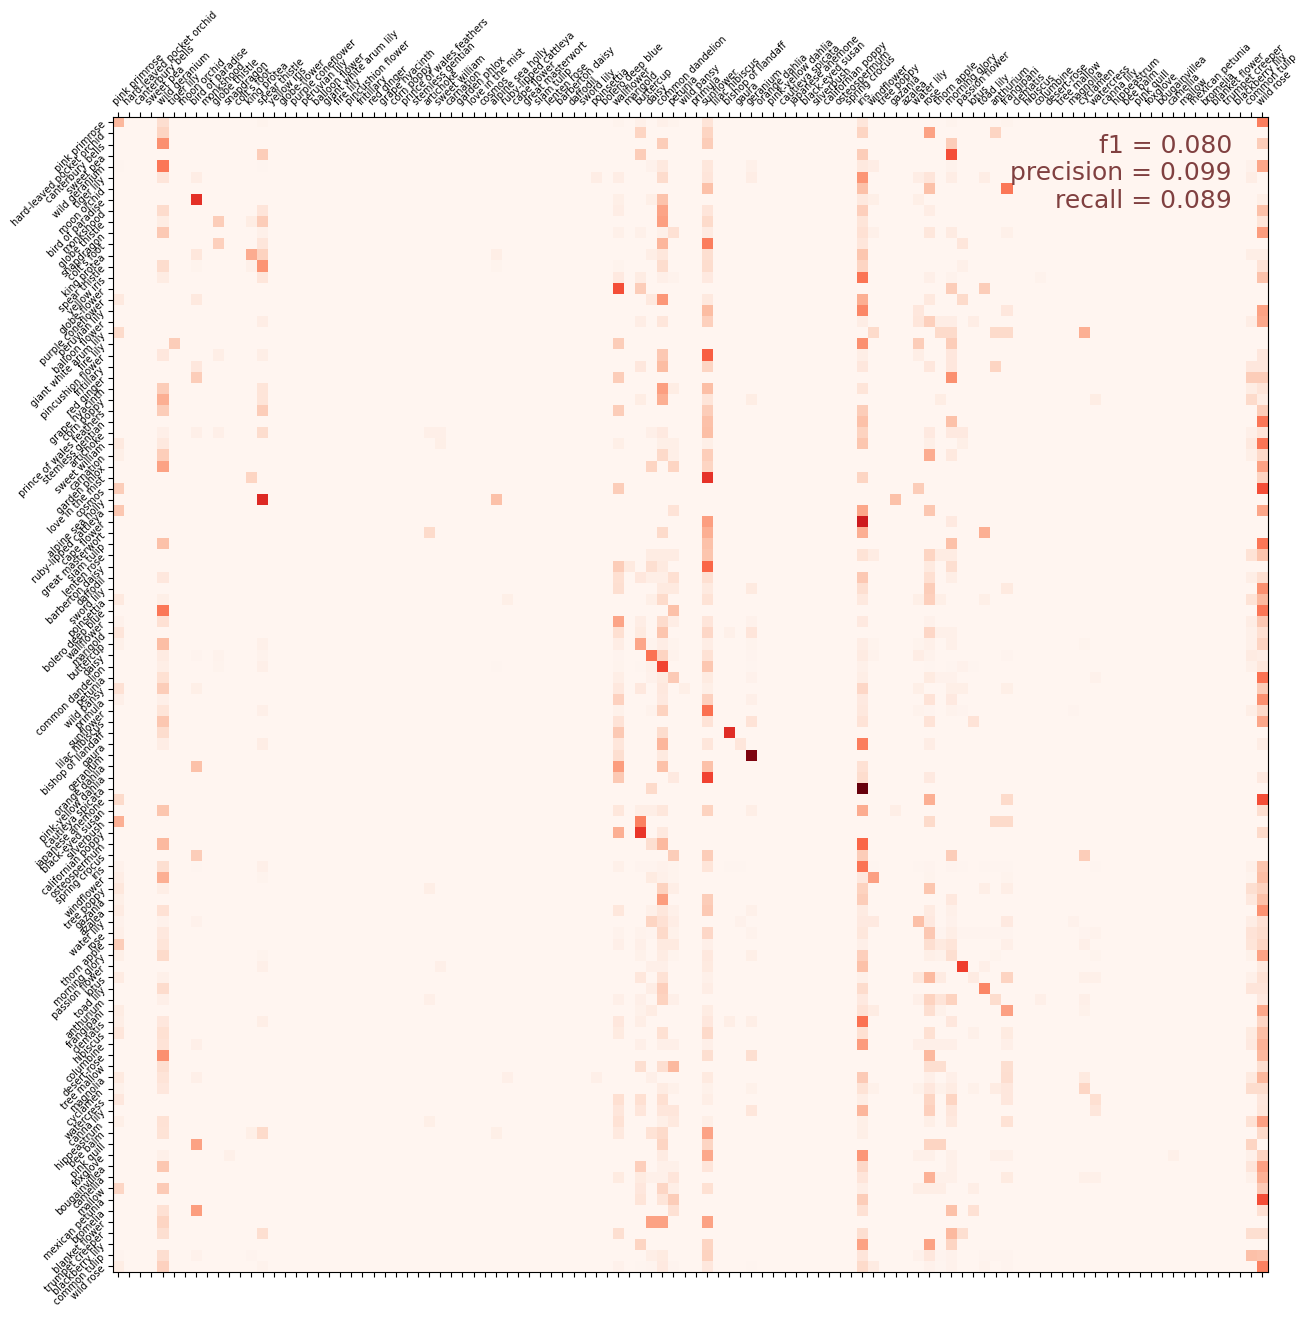

In [27]:
score = f1_score(
    cm_correct_labels,
    cm_predictions,
    labels=labels,
    average='macro',
)
precision = precision_score(
    cm_correct_labels,
    cm_predictions,
    labels=labels,
    average='macro',
)
recall = recall_score(
    cm_correct_labels,
    cm_predictions,
    labels=labels,
    average='macro',
)
display_confusion_matrix(cmat, score, precision, recall)

## Visual Validation ##

It can also be helpful to look at some examples from the validation set and see what class your model predicted. This can help reveal patterns in the kinds of images your model has trouble with.

This cell will set up the validation set to display 20 images at a time -- you can change this to display more or fewer, if you like.

In [28]:
dataset = get_validation_dataset()
dataset = dataset.unbatch().batch(20)
batch = iter(dataset)

And here is a set of flowers with their predicted species. Run the cell again to see another set.

1/1 [==============================] - 6s 6s/step


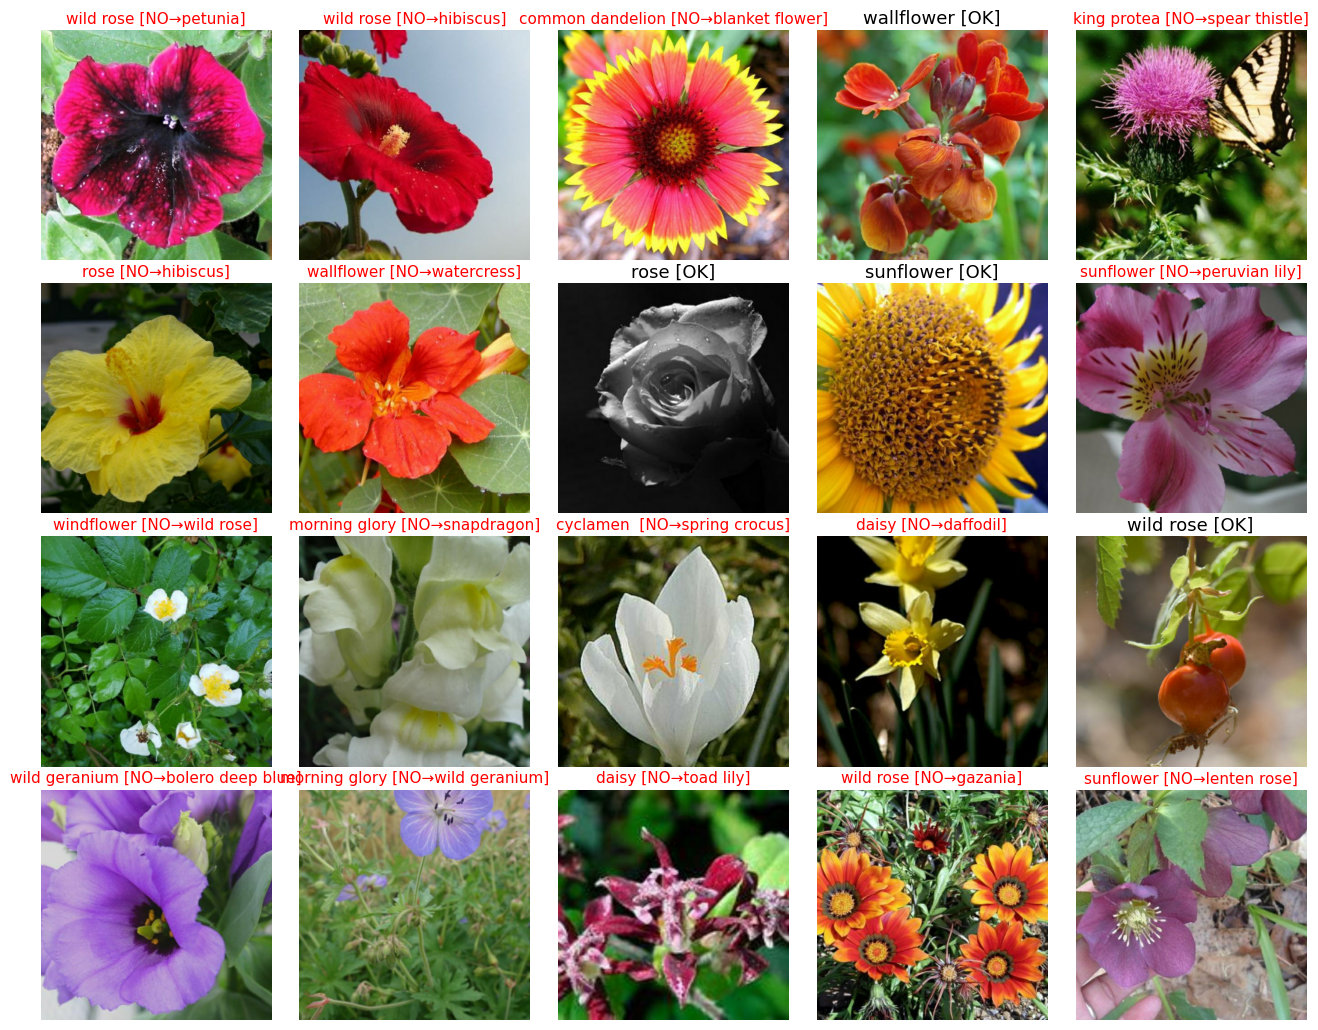

In [29]:
images, labels = next(batch)
probabilities = model.predict(images)
predictions = np.argmax(probabilities, axis=-1)
display_batch_of_images((images, labels), predictions)

# Step 8: Make Test Predictions #

Once you're satisfied with everything, you're ready to make predictions on the test set.

In [30]:
test_ds = get_test_dataset(ordered=True)

print('Computing predictions...')
test_images_ds = test_ds.map(lambda image, idnum: image)
probabilities = model.predict(test_images_ds)
predictions = np.argmax(probabilities, axis=-1)
print(predictions)

Computing predictions...
462/462 [==============================] - 1949s 4s/step
[ 67  53  75 ... 103 103  45]


We'll generate a file `submission.csv`. This file is what you'll submit to get your score on the leaderboard.

In [31]:
print('Generating submission.csv file...')

# Get image ids from test set and convert to unicode
test_ids_ds = test_ds.map(lambda image, idnum: idnum).unbatch()
test_ids = next(iter(test_ids_ds.batch(NUM_TEST_IMAGES))).numpy().astype('U')

# Write the submission file
np.savetxt(
    'submission.csv',
    np.rec.fromarrays([test_ids, predictions]),
    fmt=['%s', '%d'],
    delimiter=',',
    header='id,label',
    comments='',
)

# Look at the first few predictions
!head submission.csv

Generating submission.csv file...
id,label
252d840db,67
1c4736dea,53
dfd946ac8,75
6e644aad3,13
0c3ae4377,0
98f62f563,73
a31f90373,53
855229539,72
0bf251179,75
